In [11]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import os
import numpy as np
import torch.nn.functional as F

torch.backends.cudnn.benchmark = True

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [12]:
class SliceDataset(Dataset):
    def __init__(self, root_dir):
        self.root_dir = root_dir
        self.ct_files = [f for f in os.listdir(root_dir) if "_ct.npy" in f]

    def __len__(self):
        return len(self.ct_files)

    def __getitem__(self, idx):
        ct_name = self.ct_files[idx]
        mask_name = ct_name.replace("_ct.npy", "_mask.npy")

        ct = np.load(os.path.join(self.root_dir, ct_name))
        mask = np.load(os.path.join(self.root_dir, mask_name))

        ct = ct / np.max(ct)

        ct = torch.tensor(ct, dtype=torch.float32).unsqueeze(0)
        mask = torch.tensor(mask, dtype=torch.float32)

        # Resize
        ct = F.interpolate(ct.unsqueeze(0), size=(128,128),
                           mode='bilinear', align_corners=False).squeeze(0)

        mask = F.interpolate(mask.unsqueeze(0), size=(128,128),
                             mode='nearest').squeeze(0)

        # Convert one-hot → class index
        mask = torch.argmax(mask, dim=0)

        return ct, mask.long()

In [13]:
dataset = SliceDataset("slices")

loader = DataLoader(
    dataset,
    batch_size=16,
    shuffle=True,
    num_workers=4,
    pin_memory=True
)

In [14]:
class UNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.enc1 = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(16, 16, 3, padding=1),
            nn.ReLU()
        )

        self.pool = nn.MaxPool2d(2)

        self.enc2 = nn.Sequential(
            nn.Conv2d(16, 32, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1),
            nn.ReLU()
        )

        self.up = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)

        self.dec = nn.Sequential(
            nn.Conv2d(32, 16, 3, padding=1),
            nn.ReLU()
        )

        self.out = nn.Conv2d(16, 5, 1)

    def forward(self, x):
        x1 = self.enc1(x)
        x2 = self.pool(x1)
        x3 = self.enc2(x2)
        x4 = self.up(x3)
        x5 = self.dec(x4)
        return self.out(x5)

In [16]:
model = UNet().to(device)

# 🔥 IMPORTANT FIX (class imbalance)
class_weights = torch.tensor([0.1, 1, 1, 1, 1]).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer = optim.Adam(model.parameters(), lr=1e-3)

# AMP
scaler = torch.amp.GradScaler(device='cuda')

In [17]:
epochs = 10

for epoch in range(epochs):
    model.train()
    total_loss = 0

    print(f"\nEpoch {epoch+1}")

    for i, (ct, mask) in enumerate(loader):

        ct = ct.to(device, non_blocking=True)
        mask = mask.to(device, non_blocking=True)

        optimizer.zero_grad()

        with torch.amp.autocast(device_type='cuda'):
            output = model(ct)
            loss = criterion(output, mask)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()

        if i % 50 == 0:
            print(f"Batch {i}, Loss: {loss.item():.4f}")

    avg_loss = total_loss / len(loader)
    print(f"Epoch Loss: {avg_loss:.4f}")


Epoch 1
Batch 0, Loss: 1.6531
Batch 50, Loss: 0.4652
Batch 100, Loss: 0.4184
Batch 150, Loss: 0.5113
Batch 200, Loss: 0.5130
Batch 250, Loss: 0.4315
Batch 300, Loss: 0.4686
Batch 350, Loss: 0.3908
Batch 400, Loss: 0.4324
Batch 450, Loss: 0.3314
Batch 500, Loss: 0.3516
Batch 550, Loss: 0.4286
Batch 600, Loss: 0.4239
Batch 650, Loss: 0.3441
Epoch Loss: 0.4635

Epoch 2
Batch 0, Loss: 0.3506
Batch 50, Loss: 0.4019
Batch 100, Loss: 0.4247
Batch 150, Loss: 0.4759
Batch 200, Loss: 0.4321
Batch 250, Loss: 0.3151
Batch 300, Loss: 0.4874
Batch 350, Loss: 0.4181
Batch 400, Loss: 0.3720
Batch 450, Loss: 0.3199
Batch 500, Loss: 0.3650
Batch 550, Loss: 0.2382
Batch 600, Loss: 0.2793
Batch 650, Loss: 0.3260
Epoch Loss: 0.3634

Epoch 3
Batch 0, Loss: 0.4012
Batch 50, Loss: 0.2762
Batch 100, Loss: 0.2992
Batch 150, Loss: 0.3389
Batch 200, Loss: 0.3738
Batch 250, Loss: 0.3276
Batch 300, Loss: 0.3164
Batch 350, Loss: 0.3254
Batch 400, Loss: 0.3185
Batch 450, Loss: 0.2852
Batch 500, Loss: 0.3538
Batch 55

In [18]:
torch.save(model.state_dict(), "unet_final.pth")
print("Model saved successfully!")

Model saved successfully!


In [19]:
def dice_score(pred, target, smooth=1e-6):
    pred = torch.argmax(pred, dim=1)

    intersection = (pred == target).float().sum()
    return (2. * intersection + smooth) / (pred.numel() + target.numel() + smooth)

In [20]:
model.eval()
dice_total = 0

with torch.no_grad():
    for ct, mask in loader:
        ct = ct.to(device)
        mask = mask.to(device)

        output = model(ct)
        dice_total += dice_score(output, mask).item()

dice_avg = dice_total / len(loader)
print("Dice Score:", dice_avg)

Dice Score: 0.9664340223484237


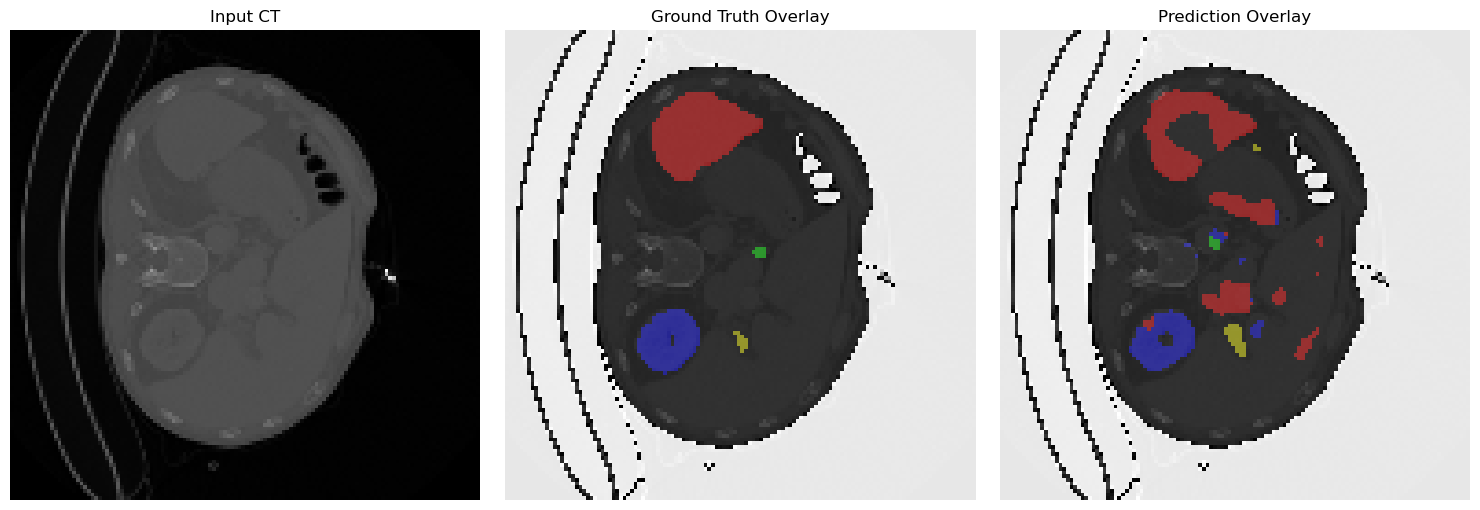

In [23]:
import matplotlib.pyplot as plt
import numpy as np

model.eval()

ct, mask = dataset[10]

with torch.no_grad():
    pred = model(ct.unsqueeze(0).to(device))
    pred = torch.argmax(pred, dim=1).cpu().squeeze(0)

# convert
ct_np = ct.squeeze().cpu().numpy()
mask_np = mask.cpu().numpy()
pred_np = pred.numpy()

# 🎨 colors
colors = np.array([
    [0, 0, 0],        # background
    [255, 0, 0],      # red
    [0, 255, 0],      # green
    [0, 0, 255],      # blue
    [255, 255, 0]     # yellow
], dtype=np.uint8)

def colorize(mask):
    return colors[mask]

mask_color = colorize(mask_np)
pred_color = colorize(pred_np)

# 🎯 OVERLAY FUNCTION
def overlay(image, mask_color, alpha=0.5):
    image = np.stack([image]*3, axis=-1)   # gray → RGB
    image = (image * 255).astype(np.uint8)
    return np.where(mask_color > 0,
                    (1-alpha)*image + alpha*mask_color,
                    image)

overlay_gt = overlay(ct_np, mask_color)
overlay_pred = overlay(ct_np, pred_color)

# 📊 plot
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.title("Input CT")
plt.imshow(ct_np, cmap='gray')
plt.axis('off')

plt.subplot(1,3,2)
plt.title("Ground Truth Overlay")
plt.imshow(overlay_gt.astype(np.uint8))
plt.axis('off')

plt.subplot(1,3,3)
plt.title("Prediction Overlay")
plt.imshow(overlay_pred.astype(np.uint8))
plt.axis('off')

plt.tight_layout()
plt.show()